In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pyodbc 

warnings.filterwarnings('ignore')

In [2]:
conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=MJ9797\\MEET9797;"
    "DATABASE=Vendor Project;"   
    "Trusted_Connection=yes;"
)

In [3]:
df = pd.read_sql("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,3252,E & J GALLO WINERY,10932,Bridlewood Blend 175 C C,9.33,13.990000,750,339,3162.869976,373,4453.27,2937.54,41.34,61966.909988,1290.400024,28.976461,1.100295,1.407984
1,10754,PERFECTA WINES,43224,Ch Beauchene Cotes du Rhone,9.20,13.990000,750,1857,17084.400167,1808,25515.92,16945.99,200.28,28720.519941,8431.519833,33.044154,0.973613,1.493522
2,9552,M S WALKER INC,35905,Catena Alta Historic Malbec,26.17,38.990002,750,320,8374.400223,295,12956.05,8440.09,32.66,55551.819733,4581.649777,35.363014,0.921875,1.547102
3,3924,HEAVEN HILL DISTILLERIES,5286,Rosita Triple Sec,2.93,3.990000,1000,3936,11532.479966,3933,15692.67,5733.63,4129.65,14069.870026,4160.190034,26.510403,0.999238,1.360737
4,8892,TRINCHERO FAMILY ESTATES,13341,Terra d'Oro Deaver Vyd Znfdl,13.24,24.990000,750,605,8010.200197,847,17737.53,9345.61,94.19,11595.970090,9727.329803,54.840385,1.400000,2.214368


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269376,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246018,0.490000,10.990000,15.990000,28.990000,7.499990e+03
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693354,123067.799573,0.710000,453.457510,3655.464971,20738.244730,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05
TotalExciseTax,10692.0,1774.226259,10975.582240,0.000000,4.800000,46.570000,418.650000,3.682428e+05


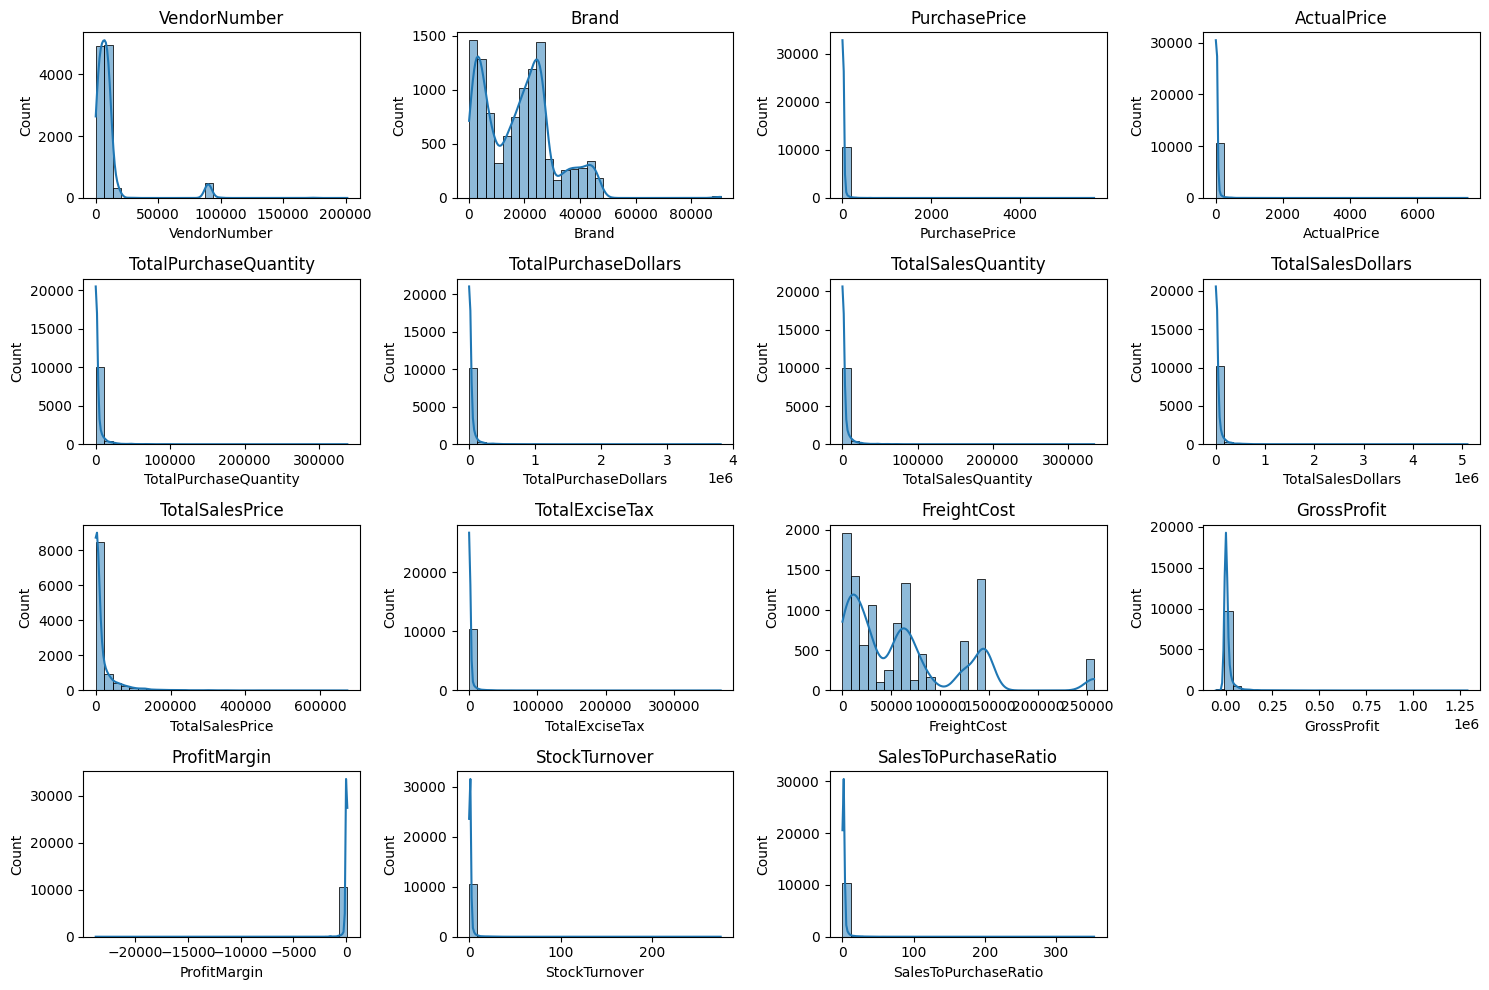

In [5]:
# Distribution Plots for Numerical Columns

numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

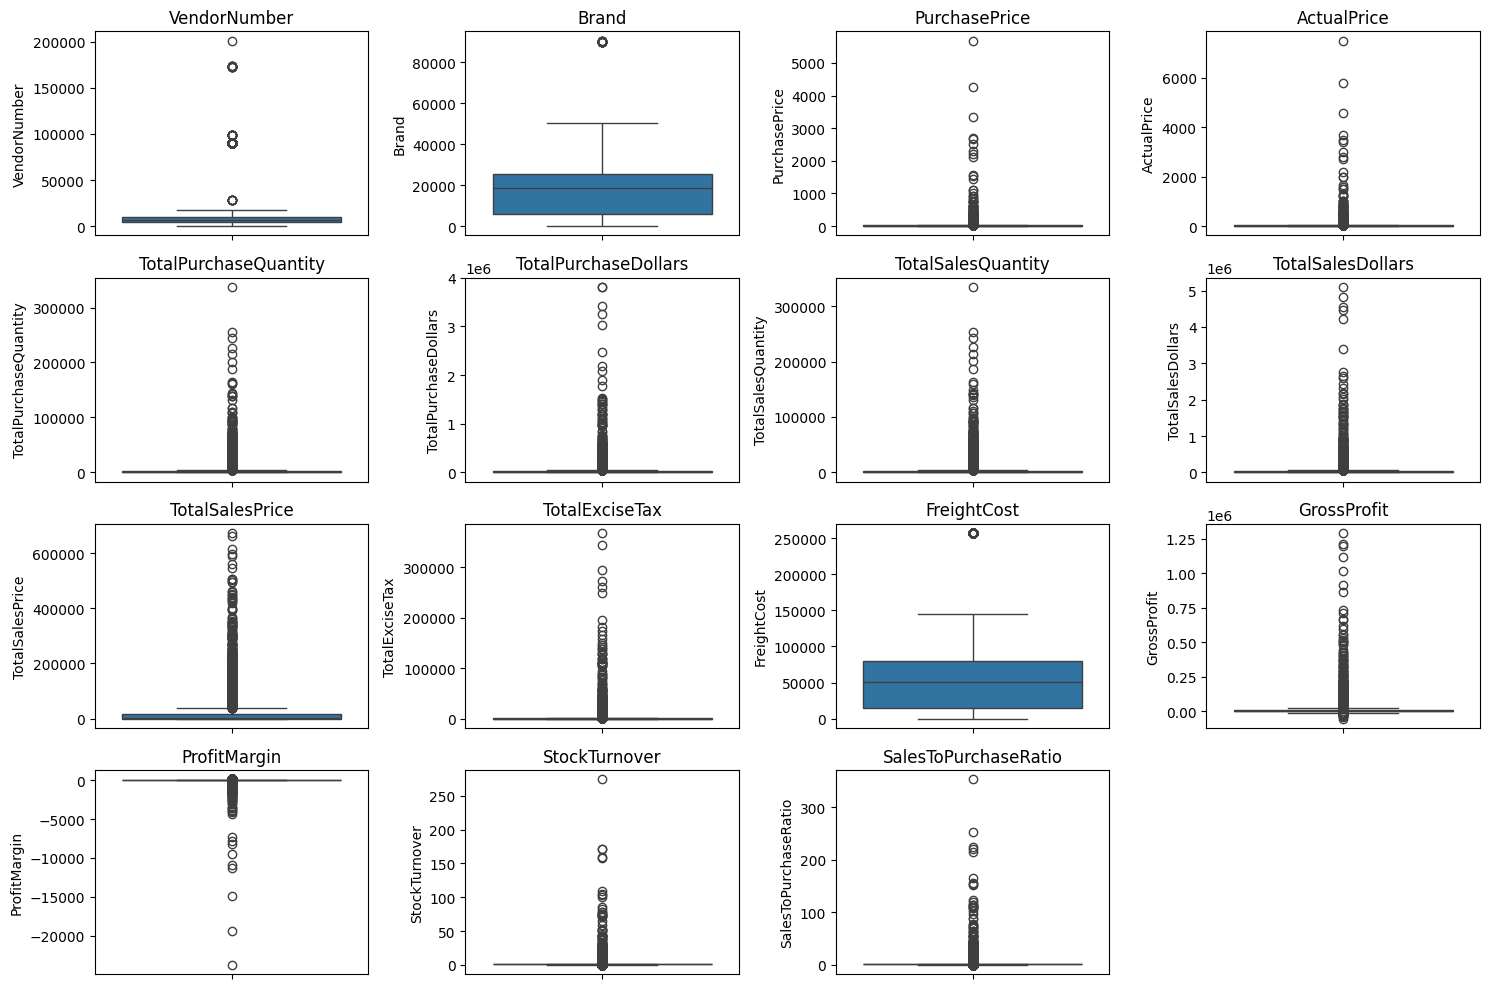

In [6]:
# Outlier Detection with Boxplots

plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [7]:
df = pd.read_sql_query("""
SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0
""", conn)

In [8]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,3252,E & J GALLO WINERY,10932,Bridlewood Blend 175 C C,9.33,13.990000,750,339,3162.869976,373,4453.27,2937.54,41.34,61966.909988,1290.400024,28.976461,1.100295,1.407984
1,10754,PERFECTA WINES,43224,Ch Beauchene Cotes du Rhone,9.20,13.990000,750,1857,17084.400167,1808,25515.92,16945.99,200.28,28720.519941,8431.519833,33.044154,0.973613,1.493522
2,9552,M S WALKER INC,35905,Catena Alta Historic Malbec,26.17,38.990002,750,320,8374.400223,295,12956.05,8440.09,32.66,55551.819733,4581.649777,35.363014,0.921875,1.547102
3,3924,HEAVEN HILL DISTILLERIES,5286,Rosita Triple Sec,2.93,3.990000,1000,3936,11532.479966,3933,15692.67,5733.63,4129.65,14069.870026,4160.190034,26.510403,0.999238,1.360737
4,8892,TRINCHERO FAMILY ESTATES,13341,Terra d'Oro Deaver Vyd Znfdl,13.24,24.990000,750,605,8010.200197,847,17737.53,9345.61,94.19,11595.970090,9727.329803,54.840385,1.400000,2.214368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,12546,JIM BEAM BRANDS COMPANY,6066,Sauza Sparkling Margarita,5.38,6.990000,750,1,5.380000,24,167.76,146.79,18.93,123880.969891,162.380000,96.793038,24.000000,31.182155
8561,90047,CRUSH WINES,22659,Iron Horse Wedding Cuvee,24.34,38.990002,750,12,292.079987,9,350.91,311.92,0.99,1457.729994,58.830013,16.764986,0.750000,1.201417
8562,9165,ULTRA BEVERAGE COMPANY LLP,17528,Dom Serene Roadblock Syrah,12.24,26.990000,750,6,73.440002,20,359.80,143.92,2.24,68054.700188,286.359998,79.588660,3.333333,4.899237
8563,4692,KOBRAND CORPORATION,15340,Caposaldo Moscato,9.45,13.990000,750,12,113.400002,12,167.88,13.99,1.35,9139.379997,54.479998,32.451750,1.000000,1.480423


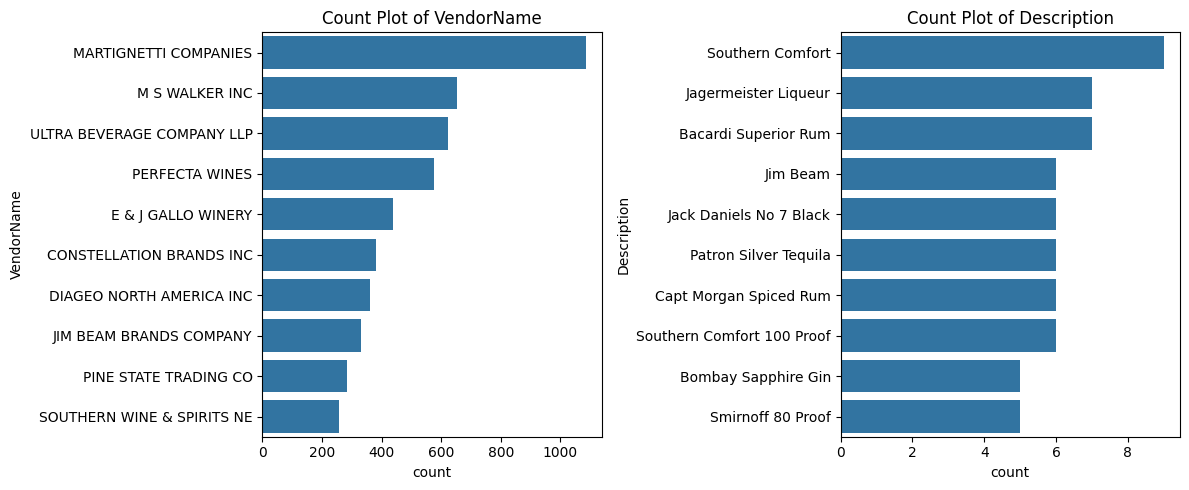

In [9]:
# Count Plots for Categorical Columns

categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index[:10]  # Top 10
    )
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()

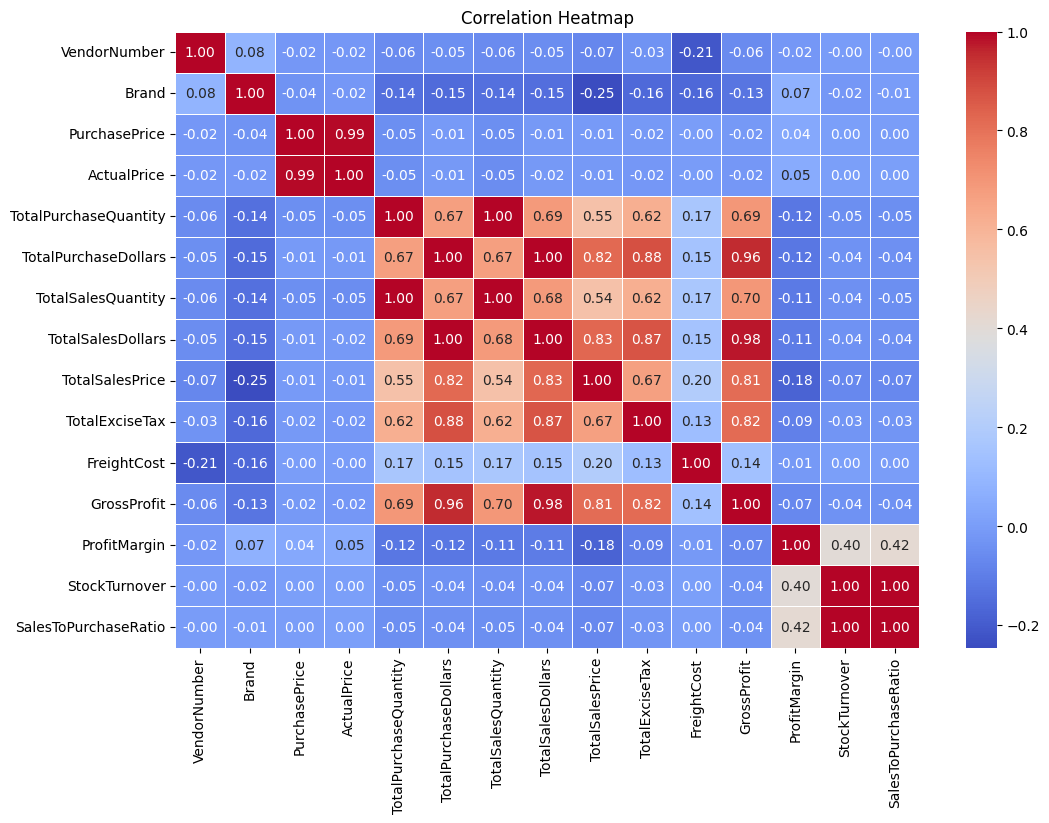

In [10]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

Correlation Insights

PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.

Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.

Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

Identify Brands that needs promotional and pricing adjustments which exhibit lower sales performance but higher profit margins

In [11]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars': 'sum',
    'ProfitMargin': 'mean'}).reset_index()

In [12]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)

In [13]:
low_sales_threshold

np.float64(560.299)

In [14]:
high_margin_threshold

np.float64(64.97017464572727)

In [15]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466467
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448275
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153077
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851583
57,A Bichot Clos Marechaudes,539.94,67.740861
6245,Sbragia Home Ranch Merlot,549.75,66.444748


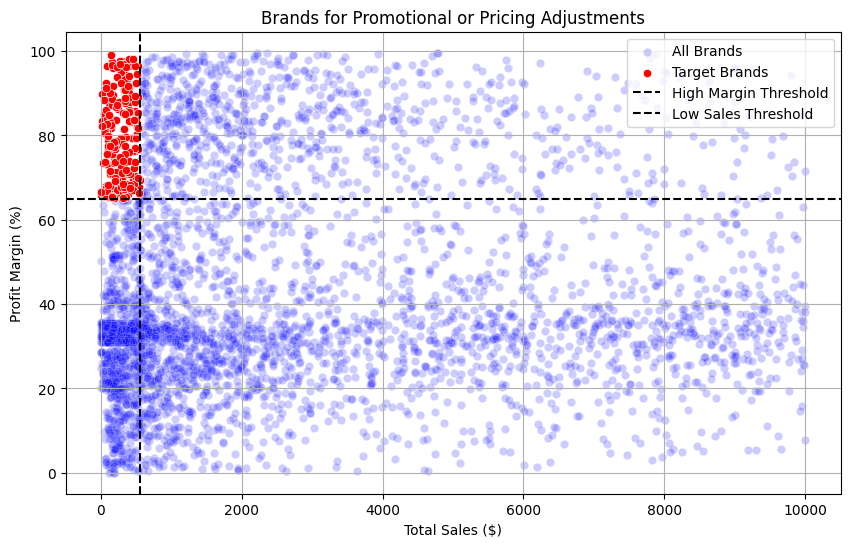

In [16]:
# Filter for better visualization (remove extreme outliers)
brand_performance_filtered = brand_performance[
    brand_performance['TotalSalesDollars'] < 10000
]

plt.figure(figsize=(10, 6))

# All brands (background)
sns.scatterplot(
    data=brand_performance_filtered,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.2
)

# Target brands (highlighted)
sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

# Threshold lines
plt.axhline(y=high_margin_threshold, linestyle='--', color='black', label='High Margin Threshold')
plt.axvline(x=low_sales_threshold, linestyle='--', color='black', label='Low Sales Threshold')

# Labels
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")

plt.legend()
plt.grid(True)
plt.show()

In [17]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [18]:
# Top Vendors by Sales
top_vendors = df.groupby('VendorName')['TotalSalesDollars'].sum().nlargest(10)

# Top Brands by Sales
top_brands = df.groupby('Description')['TotalSalesDollars'].sum().nlargest(10)

top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [19]:
top_vendors_formatted = top_vendors.apply(format_dollars)
top_brands_formatted = top_brands.apply(format_dollars)

top_vendors_formatted

VendorName
DIAGEO NORTH AMERICA INC      67.99M
MARTIGNETTI COMPANIES         39.33M
PERNOD RICARD USA             32.06M
JIM BEAM BRANDS COMPANY       31.42M
BACARDI USA INC               24.85M
CONSTELLATION BRANDS INC      24.22M
E & J GALLO WINERY            18.40M
BROWN-FORMAN CORP             18.25M
ULTRA BEVERAGE COMPANY LLP    16.50M
M S WALKER INC                14.71M
Name: TotalSalesDollars, dtype: str

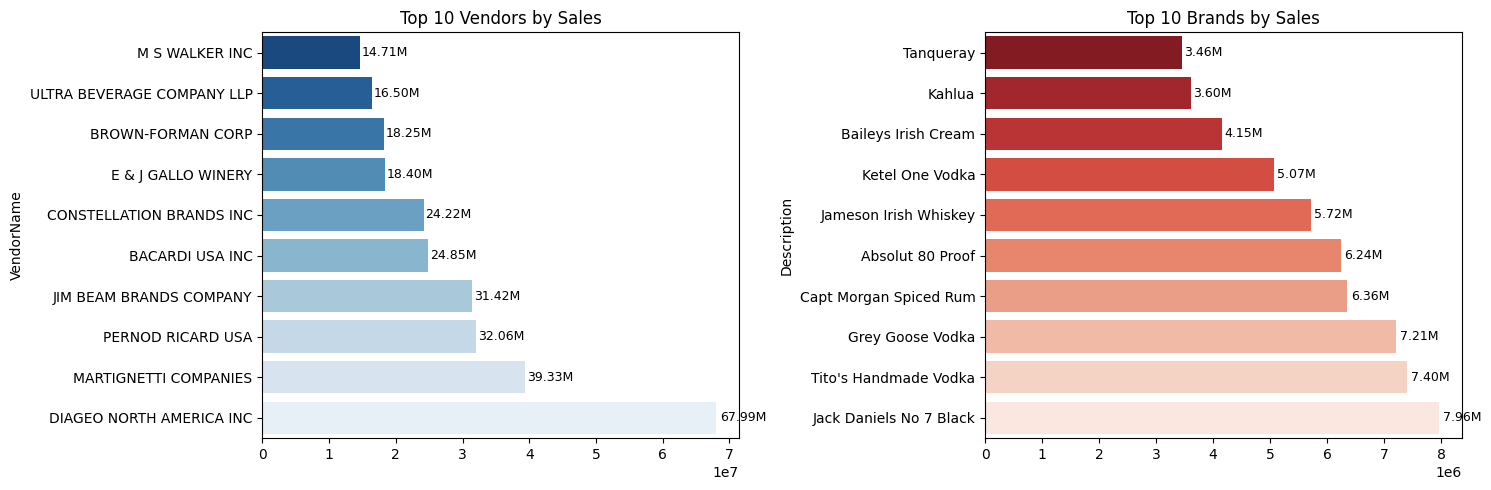

In [20]:
plt.figure(figsize=(15, 5))

# =========================
# 🔵 Top Vendors
# =========================
top_vendors_sorted = top_vendors.sort_values()

plt.subplot(1, 2, 1)
ax1 = sns.barplot(
    y=top_vendors_sorted.index,
    x=top_vendors_sorted.values,
    palette="Blues_r"
)

plt.title("Top 10 Vendors by Sales")

# Labels on bars
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        va='center',
        fontsize=9
    )

# =========================
# 🔴 Top Brands
# =========================
top_brands_sorted = top_brands.sort_values()

plt.subplot(1, 2, 2)
ax2 = sns.barplot(
    y=top_brands_sorted.index.astype(str),
    x=top_brands_sorted.values,
    palette="Reds_r"
)

plt.title("Top 10 Brands by Sales")

# Labels on bars
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.01),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [21]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars': 'sum',
    'GrossProfit': 'sum',
    'TotalSalesDollars': 'sum'
}).reset_index()

In [22]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [23]:
vendor_performance= round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

In [24]:
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.14,17892873.28,67990099.42,16.30
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.30
68,PERNOD RICARD USA,23851164.15,8212032.04,32063196.19,7.76
46,JIM BEAM BRANDS COMPANY,23494304.35,7928716.11,31423020.46,7.64
6,BACARDI USA INC,17432020.23,7422796.91,24854817.14,5.67
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
107,UNCORKED,118.74,58.20,176.94,0.00
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [25]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [26]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


In [27]:
print(top_vendors.columns)

Index(['VendorName', 'TotalPurchaseDollars', 'GrossProfit',
       'TotalSalesDollars', 'PurchaseContribution%',
       'Cumulative_Contribution%'],
      dtype='str')


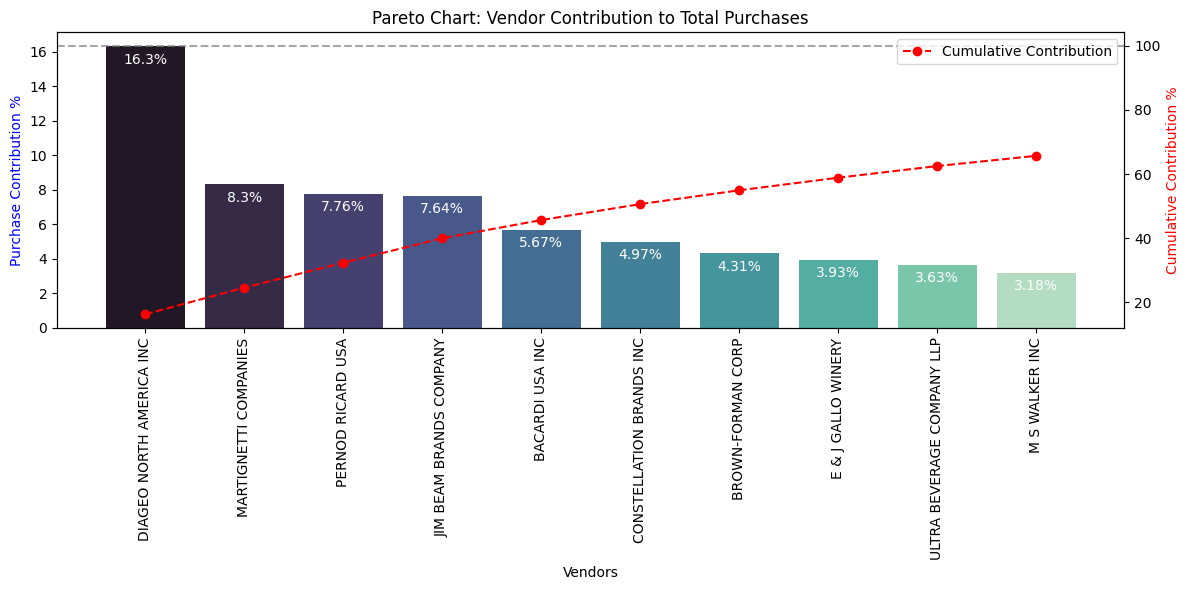

In [28]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot
sns.barplot(
    x='VendorName',
    y='PurchaseContribution%',
    data=top_vendors,
    palette='mako',
    ax=ax1
)

# Rotate labels properly
plt.xticks(rotation=90)

# Add labels on bars
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, f"{value}%", ha='center', fontsize=10, color='white')

# Line plot (Cumulative)
ax2 = ax1.twinx()
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution'
)

# Labels & title
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

# 100% line
ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [29]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.69 %


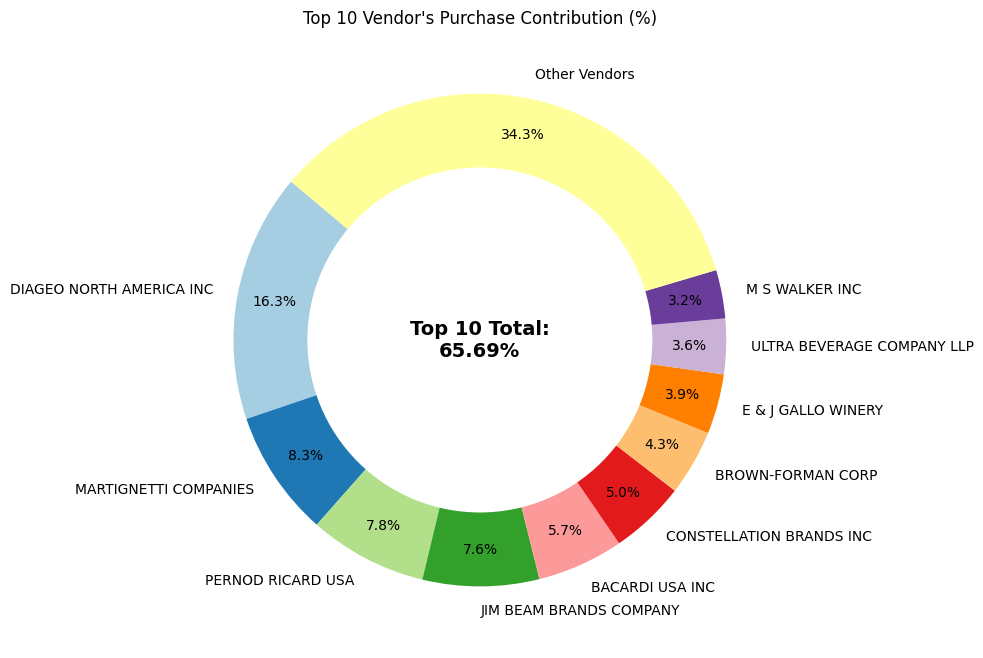

In [30]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

In [31]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [32]:
df["OrderSize"]=pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [33]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


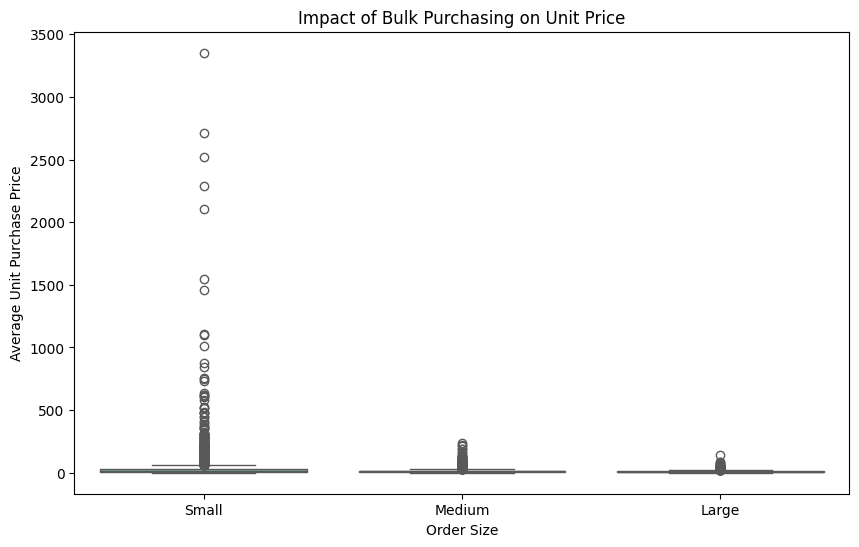

In [34]:
# Boxplot visualization
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPurchasePrice",
    palette="Set2"
)

plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")

plt.show()

-Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.

-The price difference between Small and Large orders is substantial (~72% reduction in unit cost).

-This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

In [35]:
df[df['StockTurnover'] < 1] \
    .groupby('VendorName')[['StockTurnover']] \
    .mean() \
    .sort_values('StockTurnover', ascending=True) \
    .head(10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


In [36]:
# Calculate Unsold Inventory Value
df["UnsoldInventoryValue"] = (
    (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) 
    * df["PurchasePrice"]
)

# Total unsold capital
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 2.71M


In [37]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = (
    df.groupby("VendorName")["UnsoldInventoryValue"]
    .sum()
    .reset_index()
)

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(
    by="UnsoldInventoryValue",
    ascending=False
)

# Format for display
inventory_value_per_vendor["UnsoldInventoryValue"] = (
    inventory_value_per_vendor["UnsoldInventoryValue"]
    .apply(format_dollars)
)

# Top 10 vendors
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


In [38]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [39]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [40]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [41]:
from scipy import stats

In [42]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


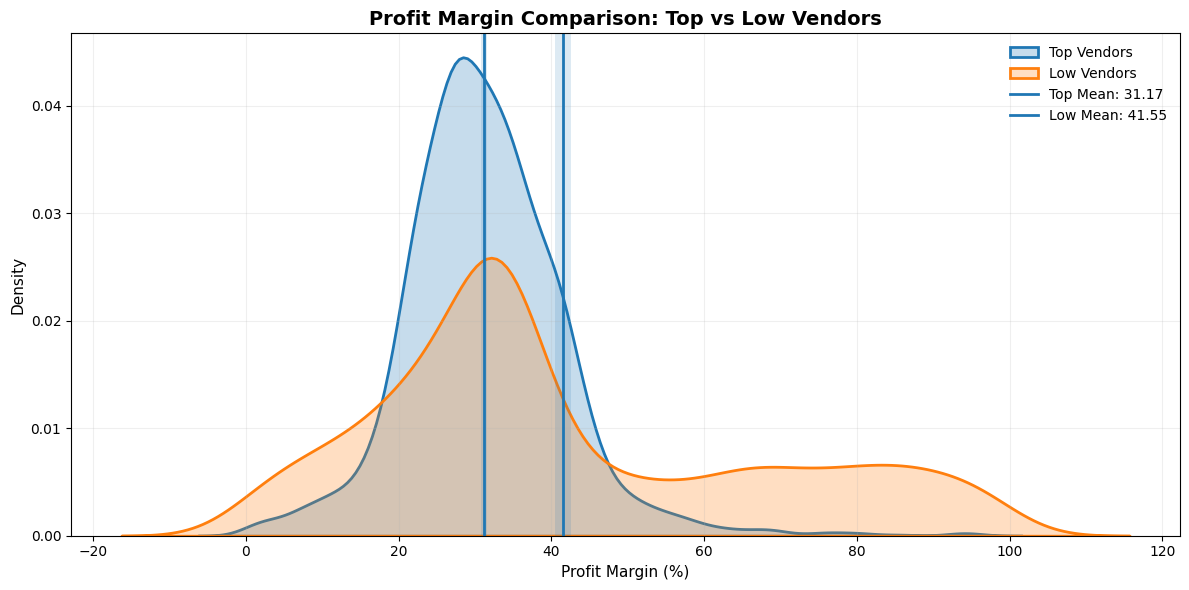

In [43]:
plt.figure(figsize=(12,6))

# Background clean
plt.gca().set_facecolor('white')

# Plot distributions (smooth + clean)
sns.kdeplot(top_vendors, fill=True, linewidth=2, label="Top Vendors")
sns.kdeplot(low_vendors, fill=True, linewidth=2, label="Low Vendors")

# Mean lines ONLY (remove clutter)
plt.axvline(top_mean, linestyle='-', linewidth=2, label=f"Top Mean: {top_mean:.2f}")
plt.axvline(low_mean, linestyle='-', linewidth=2, label=f"Low Mean: {low_mean:.2f}")

# Confidence Interval bands (clean shading)
plt.axvspan(top_lower, top_upper, alpha=0.15)
plt.axvspan(low_lower, low_upper, alpha=0.15)

# Labels
plt.title("Profit Margin Comparison: Top vs Low Vendors", fontsize=14, weight='bold')
plt.xlabel("Profit Margin (%)", fontsize=11)
plt.ylabel("Density", fontsize=11)

# Minimal grid
plt.grid(alpha=0.2)

# Clean legend
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).

This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.

For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.

For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

H₀ (Null Hypothesis):
There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis):
The mean profit margins of top-performing and low-performing vendors are significantly different.

In [44]:
# Define thresholds
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

# Split vendors
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [45]:
# Perform Two-Sample T-Test
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")

T-Statistic: -17.6440, P-Value: 0.0000
Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.


In [47]:
from sqlalchemy import create_engine

engine = create_engine(
    "mssql+pyodbc://MJ9797\\MEET9797/Vendor Project?trusted_connection=yes&driver=ODBC+Driver+17+for+SQL+Server"
)

In [48]:
df.to_sql('vendor_cleaned', engine, if_exists='replace', index=False)

51